## Task 3P – Linear Regression and Logistic Regression

This notebook applies supervised learning techniques to the UCI Automobile dataset using two related modelling tasks:

- **Linear Regression** is used to predict the continuous vehicle `price`.
- **Logistic Regression** is used to classify vehicles as luxury or non-luxury through a new binary variable called `LuxuryCar`.

`LuxuryCar` is assigned a value of 1 when the vehicle price is greater than the median price and 0 otherwise. Since this target is created directly from `price`, the price variable is excluded from the Logistic Regression predictors to avoid target leakage.

The notebook includes data inspection, missing-value treatment, exploratory analysis, categorical encoding, numerical scaling, model training, performance evaluation, feature selection and regularisation. The main objective is to compare model performance on training and testing data and assess how effectively the models generalise to unseen vehicles.

In [2]:
# ============================================================
# Task 3P - Libraries
# ============================================================

import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    RidgeCV,
    Lasso,
    LassoCV,
    LogisticRegression,
    LogisticRegressionCV
)

from sklearn.feature_selection import (
    SelectKBest,
    f_regression,
    f_classif
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")

## Data Loading & Initial Exploration

In [3]:
# Reading the complete documentation file
names_text = Path("automobile/imports-85.names").read_text(
    encoding="utf-8",
    errors="ignore"
)

# I want to extract the columns / attributes names - so first I define the section to look for (section 7)
attribute_section = names_text.split(
    "7. Attribute Information:", 1
)[1].split(
    "8. Missing Attribute Values:", 1
)[0]

# Extracting attribute names from numbered lines
column_names = re.findall(
    r"^\s+\d+\.\s*([^:]+):",
    attribute_section,
    flags=re.MULTILINE
)

# Removing any unnecessary spaces
column_names = [name.strip() for name in column_names]

print("Number of columns extracted:", len(column_names))
print(column_names)

Number of columns extracted: 26
['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']


In [4]:
# Load the data
# The dataset uses ? to represent missing values
automobile_df = pd.read_csv(
    "automobile/imports-85.data",
    header=None,
    names=column_names,
    na_values="?"
)

automobile_df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [5]:
#copying the dataframe to keep raw file
auto_data = automobile_df.copy()

In [6]:
auto_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       203 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [7]:
auto_data.describe().T

,count,mean,std,min,25%,50%,75%,max
symboling,205.0,0.834146,1.245307,-2.00,0.00,1.00,2.00,3.00
normalized-losses,164.0,122.000000,35.442168,65.00,94.00,115.00,150.00,256.00
wheel-base,205.0,98.756585,6.021776,86.60,94.50,97.00,102.40,120.90
length,205.0,174.049268,12.337289,141.10,166.30,173.20,183.10,208.10
width,205.0,65.907805,2.145204,60.30,64.10,65.50,66.90,72.30
height,205.0,53.724878,2.443522,47.80,52.00,54.10,55.50,59.80
curb-weight,205.0,2555.565854,520.680204,1488.00,2145.00,2414.00,2935.00,4066.00
engine-size,205.0,126.907317,41.642693,61.00,97.00,120.00,141.00,326.00
bore,201.0,3.329751,0.273539,2.54,3.15,3.31,3.59,3.94
stroke,201.0,3.255423,0.316717,2.07,3.11,3.29,3.41,4.17


In [8]:
categorical_features = auto_data.select_dtypes(include="object").columns
categorical_features

Index(['make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style',
       'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders',
       'fuel-system'],
      dtype='object')

#### Initial Dataset Interpretation

The Automobile dataset contains **205 records and 26 variables**, including **16 numerical features** and **10 categorical features**. The variables describe vehicle characteristics such as manufacturer, body style, engine specifications, dimensions, fuel efficiency and price.

Most columns are complete, but several contain missing values. The largest number of missing observations occurs in `normalized-losses`, with **164 non-null values out of 205**. Smaller amounts of missing data are present in `num-of-doors`, `bore`, `stroke`, `horsepower`, `peak-rpm` and the target variable `price`. Since `price` is the regression target, records with a missing price will need to be removed rather than imputed.

Vehicle prices range from **5,118 to 45,400**, with a mean of approximately **13,207** and a median of **10,295**. The mean being considerably higher than the median suggests that the price distribution is positively skewed, with a smaller number of expensive vehicles raising the average.

Other variables such as `engine-size`, `horsepower` and `curb-weight` also show wide ranges and relatively high maximum values. These may represent premium or high-performance vehicles and should be investigated further through distribution and outlier visualisations.

Overall, the dataset contains a mixture of numerical and categorical variables and will require missing-value treatment, categorical encoding and numerical scaling before supervised learning models are applied.

In [9]:
for col in categorical_features:
    print(f"Categories within Column: {auto_data[col].value_counts()}", "\n")

Categories within Column: make
toyota           32
nissan           18
mazda            17
mitsubishi       13
honda            13
subaru           12
volkswagen       12
volvo            11
peugot           11
dodge             9
mercedes-benz     8
bmw               8
audi              7
plymouth          7
saab              6
porsche           5
isuzu             4
alfa-romero       3
chevrolet         3
jaguar            3
renault           2
mercury           1
Name: count, dtype: int64 

Categories within Column: fuel-type
gas       185
diesel     20
Name: count, dtype: int64 

Categories within Column: aspiration
std      168
turbo     37
Name: count, dtype: int64 

Categories within Column: num-of-doors
four    114
two      89
Name: count, dtype: int64 

Categories within Column: body-style
sedan          96
hatchback      70
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64 

Categories within Column: drive-wheels
fwd    120
rwd     76
4wd      9


#### Zoom in to Categorical Features

The categorical variables show several important imbalances. `make` contains many categories, but Toyota, Nissan and Mazda are the most common manufacturers, while some brands appear only once or twice. One-hot encoding will therefore create several rare-category features.

Most vehicles use `gas`, standard aspiration, front-wheel drive and a front engine location. In particular, `engine-location` is highly imbalanced, with only three rear-engine vehicles, so this feature may have limited predictive value by itself.

Sedans and hatchbacks are the dominant body styles, while hardtops and convertibles are uncommon. Four-cylinder engines are also strongly dominant, and the most common engine type is `ohc`.

The category counts for `num-of-doors` total 203 rather than 205, confirming the two missing values already identified earlier.

Overall, one-hot encoding is appropriate because these categories do not have a natural numerical order. However, rare categories may produce unstable coefficients, especially given the relatively small dataset size, so their influence should be interpreted carefully.

### Data Inspection

In [10]:
missing_vals = auto_data.isnull().sum().sort_values(ascending=False)
print(missing_vals[missing_vals > 0])

normalized-losses    41
stroke                4
price                 4
bore                  4
horsepower            2
peak-rpm              2
num-of-doors          2
dtype: int64


In [11]:
auto_data.duplicated().sum()

np.int64(0)

In [12]:
# ============================================================
# B1.1 - Outlier Detection Using the IQR Method
# ============================================================

def iqr_outlier_summary(dataframe, columns=None, exclude=None):
    """
    Detect potential outliers in numerical columns using the IQR method.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Dataset to analyse.
    columns : list, optional
        Specific numerical columns to analyse.
        If None, all numerical columns are used.
    exclude : list, optional
        Columns to exclude from the analysis.

    Returns
    -------
    pandas.DataFrame
        Summary of IQR boundaries and detected outliers.
    """

    if columns is None:
        columns = dataframe.select_dtypes(include=np.number).columns.tolist()

    if exclude:
        columns = [column for column in columns if column not in exclude]

    results = []

    for column in columns:
        values = dataframe[column].dropna()

        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)

        outlier_mask = (
            (dataframe[column] < lower_bound) |
            (dataframe[column] > upper_bound)
        )

        outlier_count = outlier_mask.sum()
        outlier_percentage = (
            outlier_count / values.shape[0] * 100
            if values.shape[0] > 0 else 0
        )

        results.append({
            "Feature": column,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Lower Bound": lower_bound,
            "Upper Bound": upper_bound,
            "Outlier Count": outlier_count,
            "Outlier Percentage (%)": outlier_percentage
        })

    results_df = pd.DataFrame(results)

    return results_df.sort_values(
        by="Outlier Count",
        ascending=False
    ).reset_index(drop=True)

In [13]:
outlier_summary = iqr_outlier_summary(
    auto_data,
    exclude=["symboling"] # to avoid categocial values as those will not present outliers
)

display(outlier_summary.round(2))

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage (%)
0,compression-ratio,8.60,9.40,0.80,7.40,10.60,28,13.66
1,stroke,3.11,3.41,0.30,2.66,3.86,20,9.95
2,price,7775.00,16500.00,8725.00,-5312.50,29587.50,14,6.97
3,engine-size,97.00,141.00,44.00,31.00,207.00,10,4.88
4,width,64.10,66.90,2.80,59.90,71.10,8,3.90
5,horsepower,70.00,116.00,46.00,1.00,185.00,6,2.96
6,wheel-base,94.50,102.40,7.90,82.65,114.25,3,1.46
7,highway-mpg,25.00,34.00,9.00,11.50,47.50,3,1.46
8,city-mpg,19.00,30.00,11.00,2.50,46.50,2,0.98
9,peak-rpm,4800.00,5500.00,700.00,3750.00,6550.00,2,0.99


In [14]:
features_with_outliers = outlier_summary[
    outlier_summary["Outlier Count"] > 0
]

display(features_with_outliers.round(2))

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage (%)
0,compression-ratio,8.60,9.40,0.8,7.40,10.60,28,13.66
1,stroke,3.11,3.41,0.3,2.66,3.86,20,9.95
2,price,7775.00,16500.00,8725.0,-5312.50,29587.50,14,6.97
3,engine-size,97.00,141.00,44.0,31.00,207.00,10,4.88
4,width,64.10,66.90,2.8,59.90,71.10,8,3.90
5,horsepower,70.00,116.00,46.0,1.00,185.00,6,2.96
6,wheel-base,94.50,102.40,7.9,82.65,114.25,3,1.46
7,highway-mpg,25.00,34.00,9.0,11.50,47.50,3,1.46
8,city-mpg,19.00,30.00,11.0,2.50,46.50,2,0.98
9,peak-rpm,4800.00,5500.00,700.0,3750.00,6550.00,2,0.99


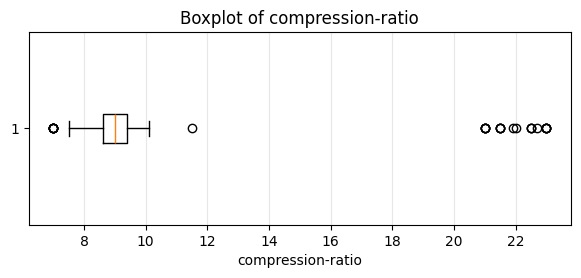

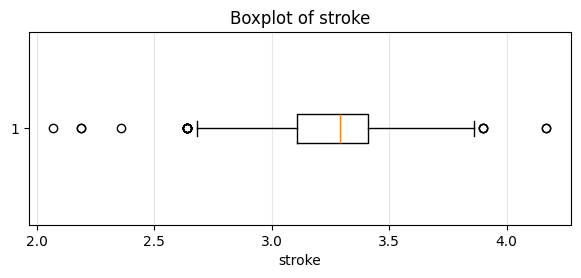

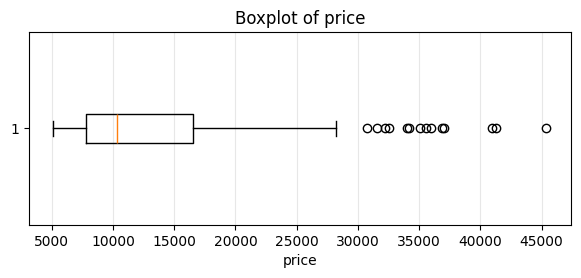

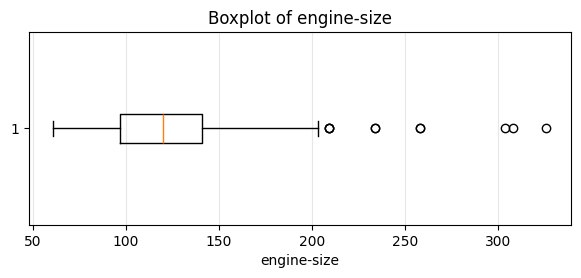

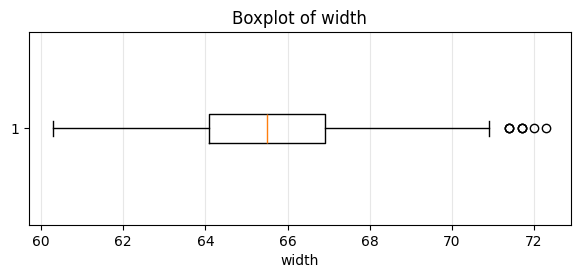

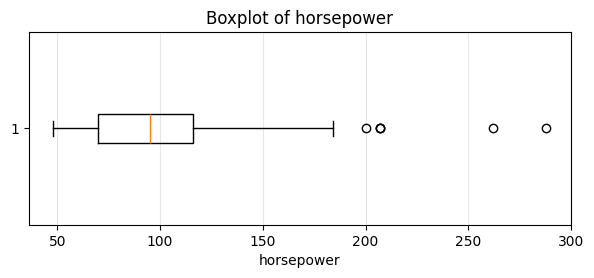

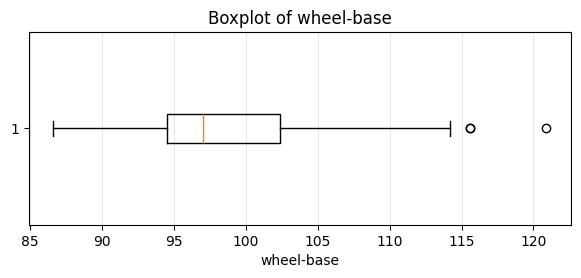

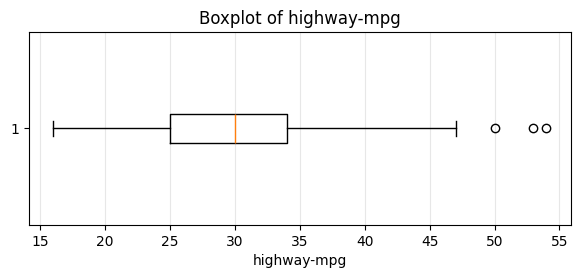

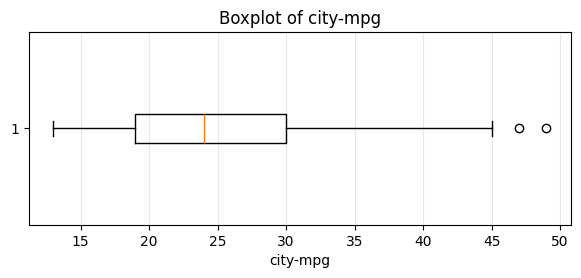

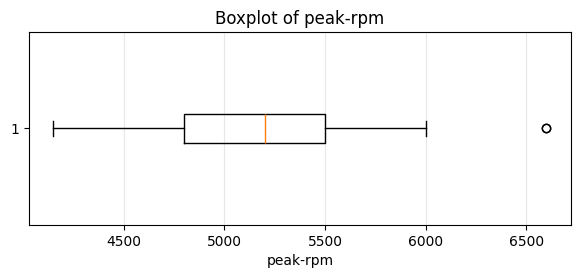

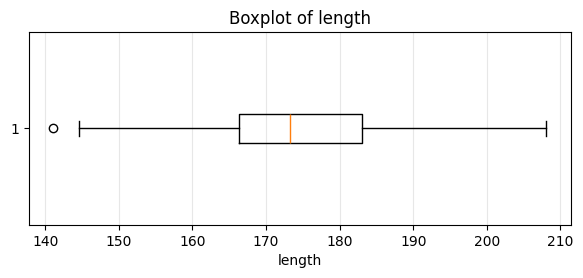

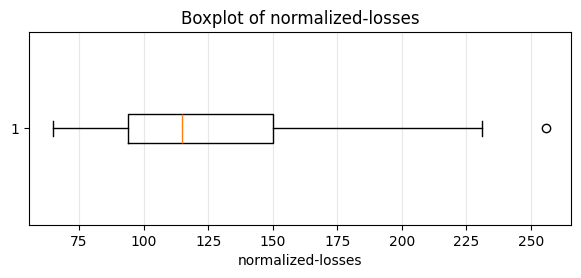

In [15]:
outlier_columns = features_with_outliers["Feature"].tolist()

for column in outlier_columns:
    plt.figure(figsize=(7, 2.5))
    plt.boxplot(auto_data[column].dropna(), vert=False)
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.grid(axis="x", alpha=0.3)
    plt.show()

#### Initial Data Quality Findings

The dataset contains **no duplicate records**, so no duplicate removal is required.

Missing values are present in several variables. The largest amount occurs in `normalized-losses` with **41 missing records**, while `stroke`, `price`, and `bore` each contain **4 missing values**. Smaller amounts are present in `horsepower`, `peak-rpm`, and `num-of-doors`.

The IQR analysis identified potential outliers in several numerical variables. The highest proportions were found in `compression-ratio` and `stroke`, followed by `price`, `engine-size`, and `width`. However, these values may represent valid vehicle characteristics, such as diesel engines, high-performance vehicles, or premium cars, rather than data errors.

Therefore, the outliers will initially be retained and investigated further during modelling and evaluation. Missing values will be treated in the next preprocessing step, while rows with missing `price` will be removed because `price` is the regression target.

## Data Preparation & Pre-Processing

### Data Imputation

In [16]:
#since the price is our target, I would not want to impute this so will drop all na values within price - they are 4 only so no major effect on data
auto_data = auto_data.dropna(subset=["price"]).reset_index(drop=True)
print("Remaining rows:", len(auto_data))

Remaining rows: 201


In [17]:
auto_data.isnull().sum()[auto_data.isnull().sum() > 0]

normalized-losses    37
num-of-doors          2
bore                  4
stroke                4
horsepower            2
peak-rpm              2
dtype: int64

In [18]:
#I want to separate missing numerical and categorical independent variables
numeric_missing = auto_data.select_dtypes(include=np.number).columns[
    auto_data.select_dtypes(include=np.number).isnull().any()
].tolist()

categorical_missing = auto_data.select_dtypes(exclude=np.number).columns[
    auto_data.select_dtypes(exclude=np.number).isnull().any()
].tolist()

print("Numerical columns requiring median imputation:", numeric_missing)
print("Categorical columns requiring mode imputation:", categorical_missing)

Numerical columns requiring median imputation: ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm']
Categorical columns requiring mode imputation: ['num-of-doors']


#### Missing-Value Treatment Rationale

- Rows with missing `price` were removed because `price` is the regression target and should not be estimated before model training.

- The remaining missing numerical predictors: `normalized-losses`, `bore`, `stroke`, `horsepower`, and `peak-rpm`, will be imputed using the **median**. The median is suitable because it is less affected by skewed values and potential outliers than the mean.

- The missing categorical values in `num-of-doors` will be replaced using the **most frequent category**, since this preserves an existing valid category without creating an artificial value.

- These imputations will be performed within the preprocessing pipeline using the training data only, which helps prevent data leakage.

In [19]:
# a cleaned copy for inspection and EDA
auto_data_clean = auto_data.copy()

# Median imputation for numerical predictors
auto_data_clean[numeric_missing] = SimpleImputer(
    strategy="median"
).fit_transform(auto_data_clean[numeric_missing])

# Most-frequent imputation for categorical predictors
auto_data_clean[categorical_missing] = SimpleImputer(
    strategy="most_frequent"
).fit_transform(auto_data_clean[categorical_missing])

# quick check
print("Remaining missing values:", auto_data_clean.isnull().sum().sum())

Remaining missing values: 0


#### Data Conversion

In [20]:
# Defining categorical columns
categorical_columns = auto_data_clean.select_dtypes(include='object').columns
categorical_columns

Index(['make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style',
       'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders',
       'fuel-system'],
      dtype='object')

In [21]:
# Converting object columns to categorical dtype
auto_data_clean[categorical_columns] = auto_data_clean[categorical_columns].astype("category")

auto_data_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   symboling          201 non-null    int64   
 1   normalized-losses  201 non-null    float64 
 2   make               201 non-null    category
 3   fuel-type          201 non-null    category
 4   aspiration         201 non-null    category
 5   num-of-doors       201 non-null    category
 6   body-style         201 non-null    category
 7   drive-wheels       201 non-null    category
 8   engine-location    201 non-null    category
 9   wheel-base         201 non-null    float64 
 10  length             201 non-null    float64 
 11  width              201 non-null    float64 
 12  height             201 non-null    float64 
 13  curb-weight        201 non-null    int64   
 14  engine-type        201 non-null    category
 15  num-of-cylinders   201 non-null    category
 16  engine-s

### Feature Engineering | Creating Luxury car Binary target

In [22]:
# Calculating the median vehicle price
median_price = auto_data_clean["price"].median()
median_price

np.float64(10295.0)

In [23]:
# 1 = price above the median
# 0 = price equal to or below the median
auto_data_clean["LuxuryCar"] = (auto_data_clean["price"] > median_price).astype(int)
auto_data_clean.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,LuxuryCar
0,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0,1
1,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0,1
2,1,115.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0,1
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0,1
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0,1


In [24]:
# Calculating class counts and percentages
class_counts = auto_data_clean["LuxuryCar"].value_counts().sort_index()

class_percentages = (
    auto_data_clean["LuxuryCar"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

luxury_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage (%)": class_percentages.round(2)
})

luxury_summary.index = luxury_summary.index.map({
    0: "Non-Luxury (0)",
    1: "Luxury (1)"
})

print(f"Median vehicle price: ${median_price:,.2f}")
display(luxury_summary)

Median vehicle price: $10,295.00


,Count,Percentage (%)
LuxuryCar,,
Non-Luxury (0),101,50.25
Luxury (1),100,49.75


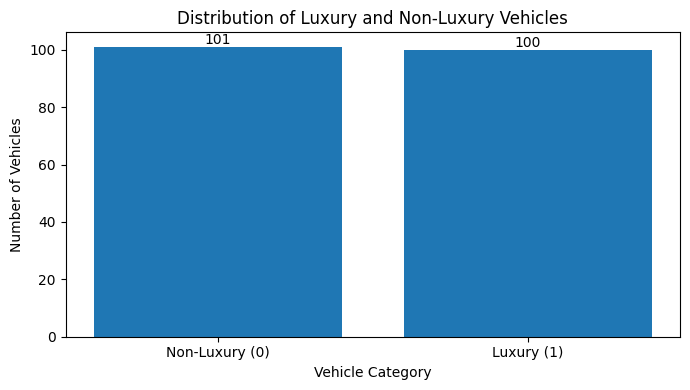

In [25]:
# plotting the new variable distribution
plt.figure(figsize=(7, 4))

bars = plt.bar(
    luxury_summary.index,
    luxury_summary["Count"]
)

plt.title("Distribution of Luxury and Non-Luxury Vehicles")
plt.xlabel("Vehicle Category")
plt.ylabel("Number of Vehicles")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        int(bar.get_height()),
        ha="center"
    )

plt.tight_layout()
plt.show()

#### LuxuryCar Class Distribution

The newly created `LuxuryCar` variable produced an approximately balanced class distribution. This is expected because the median vehicle price was used as the classification threshold. Vehicles priced above the median were classified as luxury, while vehicles priced at or below the median were classified as non-luxury.

The balanced distribution is helpful for classification because neither class is substantially under-represented.

### Visualization | Univariate & Bivariate Analysis

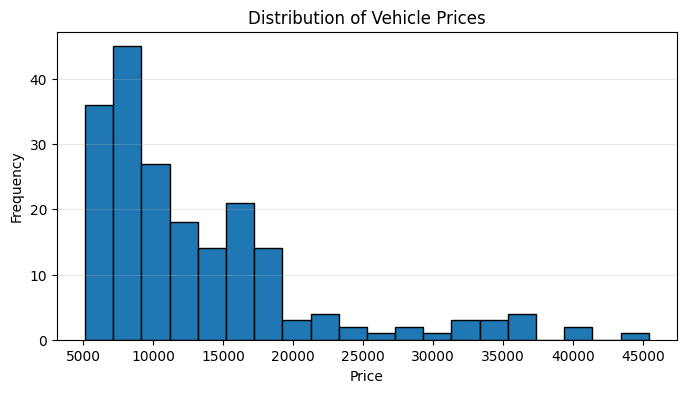

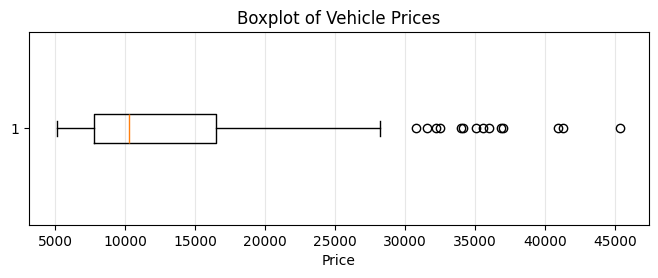

Price skewness: 1.81


In [26]:
# ============================================================
# Univariate Analysis - Price Distribution
# ============================================================

plt.figure(figsize=(8, 4))
plt.hist(auto_data_clean["price"], bins=20, edgecolor="black")
plt.title("Distribution of Vehicle Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(8, 2.5))
plt.boxplot(auto_data_clean["price"], vert=False)
plt.title("Boxplot of Vehicle Prices")
plt.xlabel("Price")
plt.grid(axis="x", alpha=0.3)
plt.show()

print(f"Price skewness: {auto_data_clean['price'].skew():.2f}")

,Correlation with Price
engine-size,0.872
curb-weight,0.834
horsepower,0.811
width,0.751
length,0.691
wheel-base,0.585
bore,0.543
height,0.135
normalized-losses,0.094
stroke,0.082


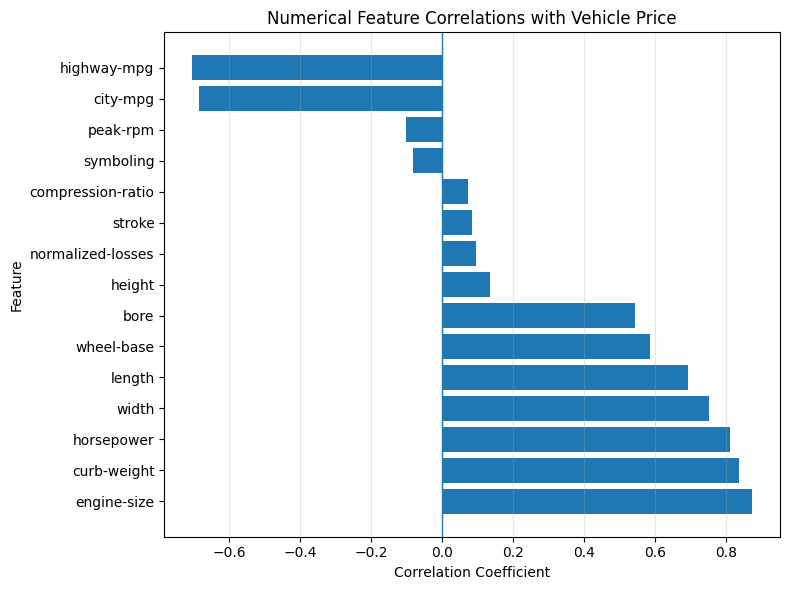

In [27]:
# ============================================================
# Bivariate Analysis - Numerical Correlation with Price
# ============================================================

numerical_features = auto_data_clean.select_dtypes(
    include=np.number
).columns.drop(["price", "LuxuryCar"])

price_correlations = (
    auto_data_clean[numerical_features.tolist() + ["price"]]
    .corr()["price"]
    .drop("price")
    .sort_values(ascending=False)
)

display(
    price_correlations
    .rename("Correlation with Price")
    .to_frame()
    .round(3)
)

plt.figure(figsize=(8, 6))
plt.barh(price_correlations.index, price_correlations.values)
plt.title("Numerical Feature Correlations with Vehicle Price")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.axvline(0, linewidth=1)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

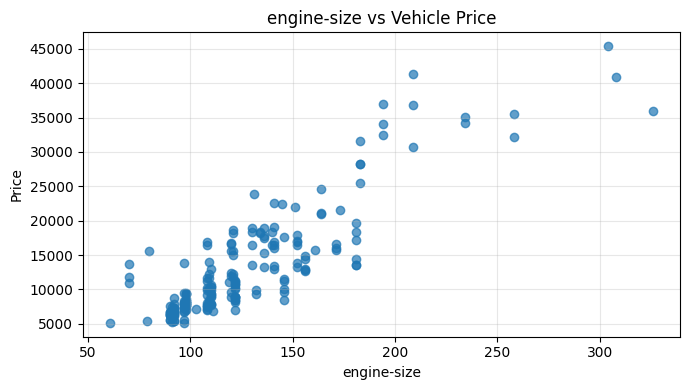

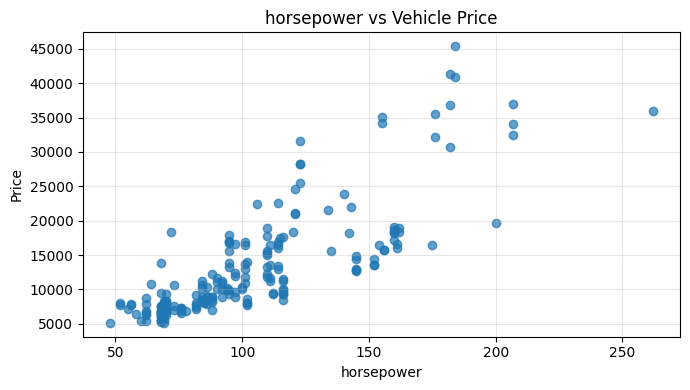

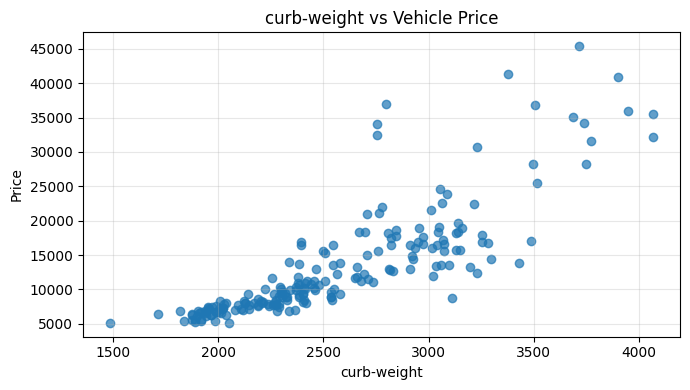

In [28]:
# ============================================================
# Bivariate Analysis - Key Numerical Features vs Price
# ============================================================

key_features = ["engine-size", "horsepower", "curb-weight"]

for feature in key_features:
    plt.figure(figsize=(7, 4))
    plt.scatter(
        auto_data_clean[feature],
        auto_data_clean["price"],
        alpha=0.7
    )
    plt.title(f"{feature} vs Vehicle Price")
    plt.xlabel(feature)
    plt.ylabel("Price")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

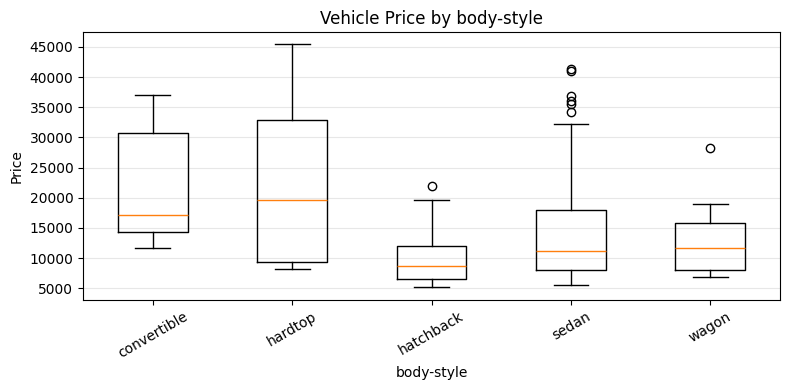

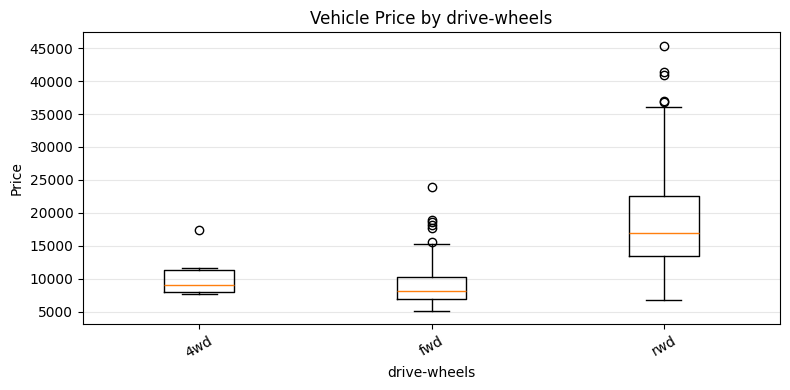

In [29]:
# ============================================================
# Bivariate Analysis - Price by Categorical Features
# ============================================================

categorical_price_features = ["body-style", "drive-wheels"]

for feature in categorical_price_features:
    categories = auto_data_clean[feature].cat.categories

    grouped_prices = [
        auto_data_clean.loc[
            auto_data_clean[feature] == category,
            "price"
        ]
        for category in categories
    ]

    plt.figure(figsize=(8, 4))
    plt.boxplot(grouped_prices, labels=categories)
    plt.title(f"Vehicle Price by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Price")
    plt.xticks(rotation=30)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

#### Univariate and Bivariate Analysis – Initial Findings

- **Vehicle price distribution**
  - Vehicle prices are strongly positively skewed, with a skewness value of **1.81**.
  - Most vehicles are concentrated below approximately **$20,000**, while a smaller number of premium vehicles extend beyond **$30,000**.
  - The boxplot identifies several high-price observations, but these are likely valid luxury or high-performance vehicles rather than data errors.
  - These high-value vehicles will be retained and their influence assessed later through model residuals and testing performance.

- **Numerical relationships with price**
  - `engine-size` shows the strongest positive correlation with price.
  - `curb-weight`, `horsepower`, `width`, and `length` also have strong positive relationships with price.
  - Larger, heavier, and more powerful vehicles generally have higher prices.
  - `city-mpg` and `highway-mpg` have strong negative relationships with price, suggesting that more expensive and powerful vehicles often have lower fuel efficiency.
  - Variables such as `peak-rpm`, `symboling`, `stroke`, and `compression-ratio` show relatively weak direct correlations with price.

- **Key numerical scatter plots**
  - `engine-size`, `horsepower`, and `curb-weight` all show clear positive relationships with vehicle price.
  - The relationships are strongest among lower- and mid-priced vehicles, while greater variation appears among high-priced vehicles.
  - Some premium vehicles may act as influential observations, but they remain realistic and relevant to the prediction task.
  - The patterns support the use of Linear Regression, although the increasing price variation may indicate that the relationships are not perfectly linear.

- **Vehicle price by body style**
  - Hardtops and convertibles generally have higher median prices, although these categories contain relatively few vehicles.
  - Hatchbacks have the lowest median price and are mainly concentrated in the lower-price range.
  - Sedans show a wide price range, including several premium vehicles.
  - Wagons generally fall within the lower-to-middle price range, with one notable high-price observation.

- **Vehicle price by drive wheels**
  - Rear-wheel-drive (`rwd`) vehicles have the highest median price and the widest price range.
  - Front-wheel-drive (`fwd`) vehicles are mostly concentrated in the lower-price range.
  - Four-wheel-drive (`4wd`) vehicles also appear relatively low-priced, but this category contains only a small number of observations.
  - Drive-wheel configuration may therefore be a useful categorical predictor of vehicle price.

- **Initial modelling implication**
  - Engine power, vehicle size, weight, fuel efficiency, body style, and drive-wheel configuration appear useful for predicting vehicle price.
  - Several numerical predictors are likely related to each other, particularly `engine-size`, `horsepower`, `curb-weight`, `width`, and `length`.
  - A correlation heatmap should therefore be examined next to identify possible multicollinearity before proceeding to encoding and scaling.

### A Zoom In on Luxury Car Class

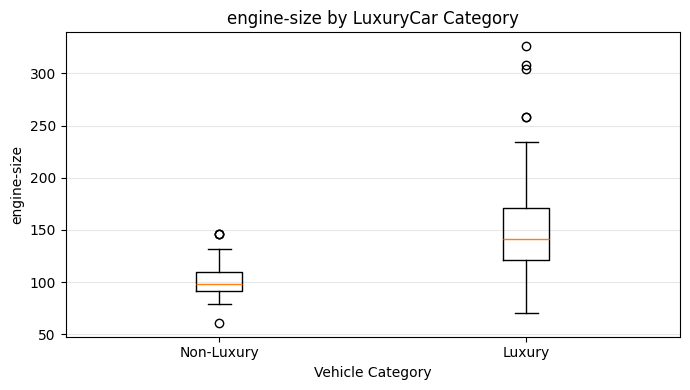

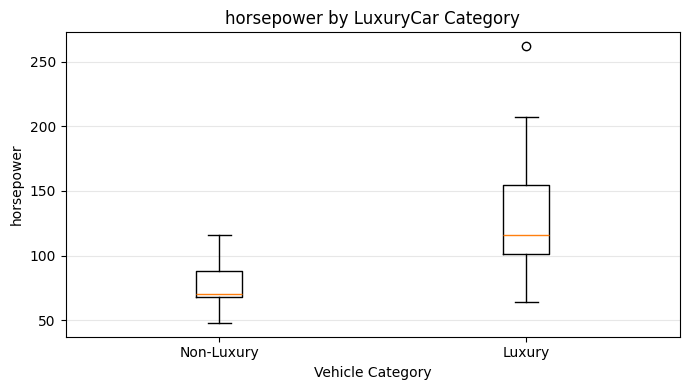

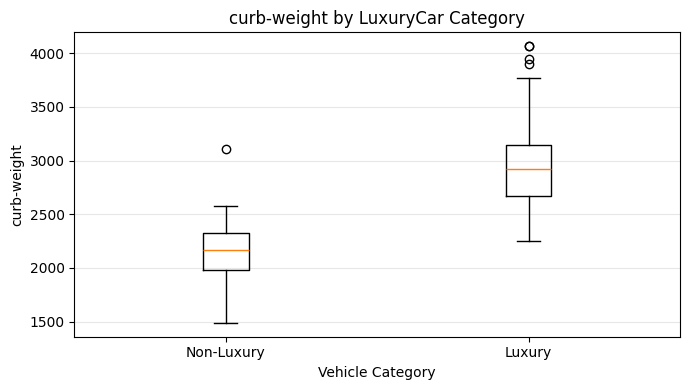

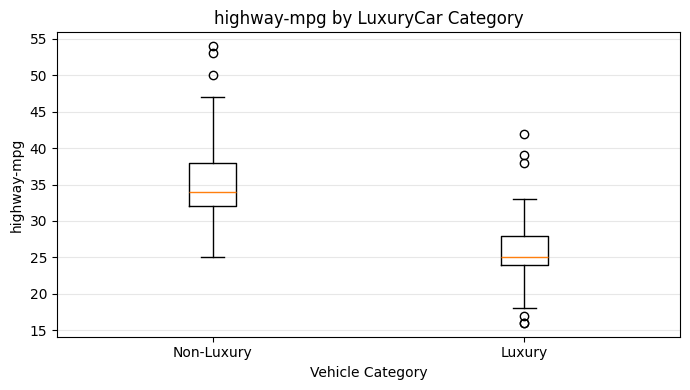

In [30]:
luxury_numeric_features = [
    "engine-size",
    "horsepower",
    "curb-weight",
    "highway-mpg"
]

for feature in luxury_numeric_features:
    grouped_values = [
        auto_data_clean.loc[
            auto_data_clean["LuxuryCar"] == luxury_class,
            feature
        ]
        for luxury_class in [0, 1]
    ]

    plt.figure(figsize=(7, 4))
    plt.boxplot(
        grouped_values,
        tick_labels=["Non-Luxury", "Luxury"]
    )
    plt.title(f"{feature} by LuxuryCar Category")
    plt.xlabel("Vehicle Category")
    plt.ylabel(feature)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

,Non-Luxury (%),Luxury (%)
body-style,,
convertible,0.0,100.0
hardtop,37.5,62.5
hatchback,63.2,36.8
sedan,45.7,54.3
wagon,48.0,52.0


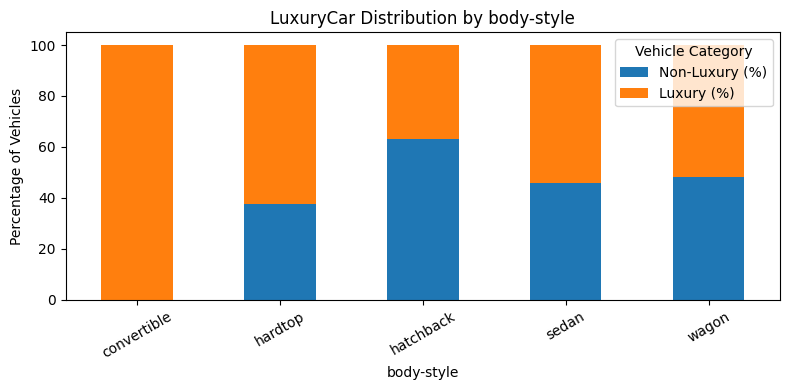

,Non-Luxury (%),Luxury (%)
drive-wheels,,
4wd,62.5,37.5
fwd,74.6,25.4
rwd,10.7,89.3


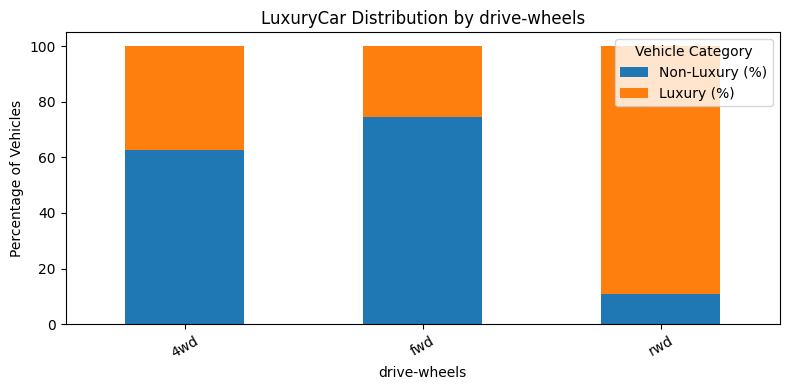

In [31]:
for feature in ["body-style", "drive-wheels"]:
    luxury_distribution = pd.crosstab(
        auto_data_clean[feature],
        auto_data_clean["LuxuryCar"],
        normalize="index"
    ) * 100

    luxury_distribution.columns = ["Non-Luxury (%)", "Luxury (%)"]

    display(luxury_distribution.round(1))

    luxury_distribution.plot(
        kind="bar",
        stacked=True,
        figsize=(8, 4)
    )

    plt.title(f"LuxuryCar Distribution by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Percentage of Vehicles")
    plt.xticks(rotation=30)
    plt.legend(title="Vehicle Category")
    plt.tight_layout()
    plt.show()

#### LuxuryCar Feature Patterns

- Luxury vehicles generally show higher values for `engine-size`, `horsepower`, and `curb-weight`.
- `highway-mpg` is lower for luxury vehicles, which is reasonable because larger and more powerful vehicles are often less fuel-efficient.
- Convertibles and hardtops contain a high proportion of luxury vehicles.
- Rear-wheel-drive vehicles are strongly associated with the luxury category, while front-wheel-drive vehicles are mostly non-luxury.

**Important:** `LuxuryCar` was created directly from `price`. Therefore, I will be excluding `price` from the Logistic Regression input features to avoid target leakage.

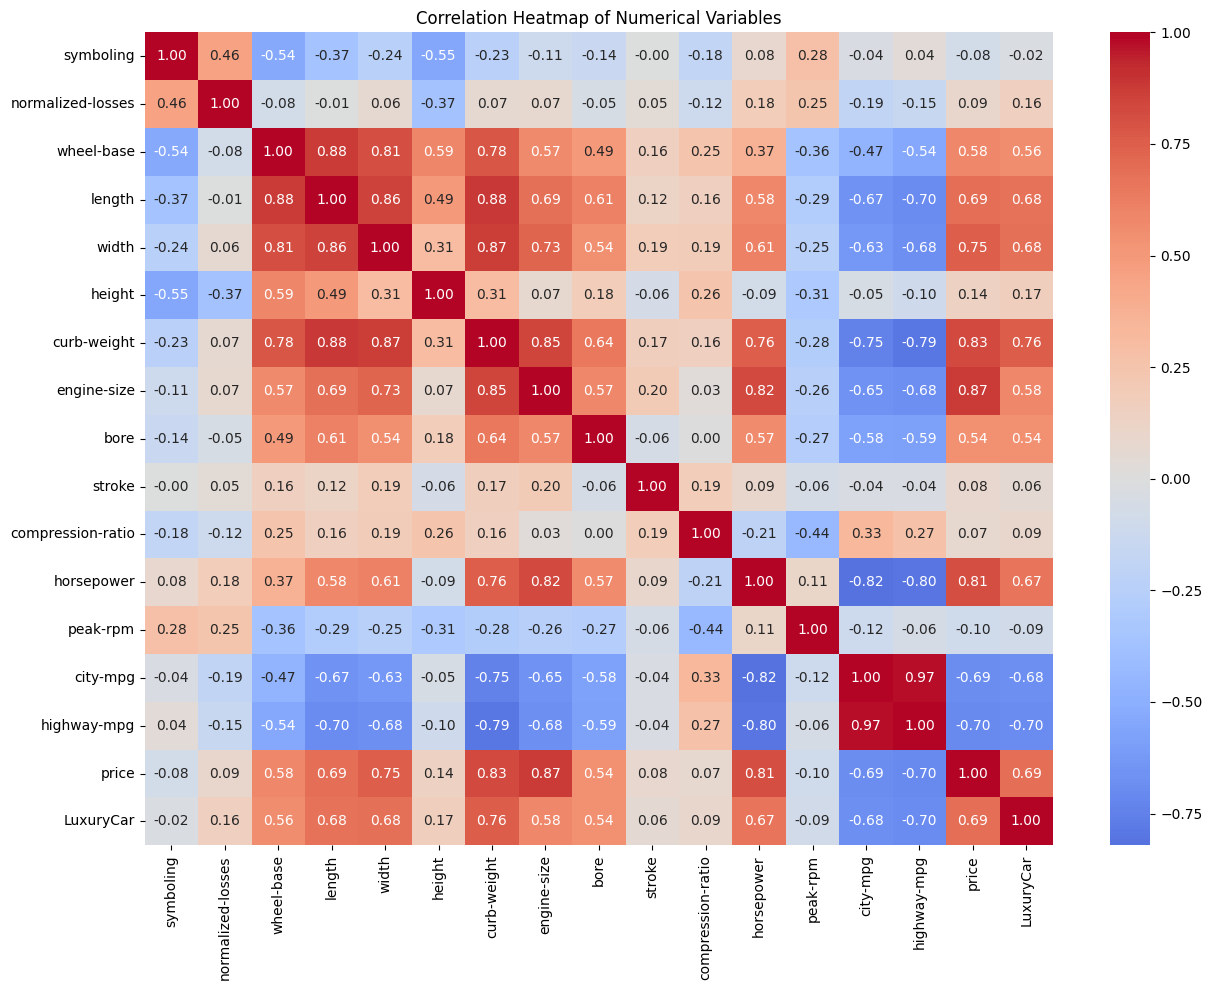

In [32]:
# wrapping up with a full correlation heatmap
correlation_matrix = auto_data_clean.corr(numeric_only=True)

plt.figure(figsize=(13, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

#### Correlation Heatmap – Key Observations

- `engine-size` has the strongest positive correlation with `price` (**0.87**).
- `curb-weight` (**0.83**) and `horsepower` (**0.81**) are also strongly related to price.
- `city-mpg` and `highway-mpg` are negatively correlated with price (**−0.69** and **−0.70**).
- `LuxuryCar` is most associated with `curb-weight` (**0.76**), `width` (**0.68**), `length` (**0.68**) and `horsepower` (**0.67**).
- `city-mpg` and `highway-mpg` are strongly negatively related to `LuxuryCar`.
- Several predictors are highly correlated with each other, indicating possible multicollinearity.
- The correlation between `price` and `LuxuryCar` is expected because `LuxuryCar` was created using the median price.

These are some useful observations that would help us in the Linear then Logistic regression down the stream, it is already giving us hints what are the strong predictors that we need to consider part of our training dataset

### Predictors, Targets and Train-Test Split

In [33]:
# Common predictor variables
X = auto_data_clean.drop(columns=["price", "LuxuryCar"])

# Regression target
y_price = auto_data_clean["price"]

# Classification target
y_luxury = auto_data_clean["LuxuryCar"]

print("Predictor shape:", X.shape)
print("Price target shape:", y_price.shape)
print("Luxury target shape:", y_luxury.shape)

Predictor shape: (201, 25)
Price target shape: (201,)
Luxury target shape: (201,)


In [34]:
# now for the test-train split to prepare for Linear Regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_price, test_size=0.20, random_state=42)

print("Regression training records:", X_train_reg.shape[0])
print("Regression testing records:", X_test_reg.shape[0])

Regression training records: 160
Regression testing records: 41


In [35]:
#and the split for later when we apply the logistic regression classifer (for luxury cars)
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X, y_luxury, test_size=0.20, random_state=42, stratify=y_luxury)

print("Logistic Regression training records:", X_train_cls.shape[0])
print("Logistic Regression testing records:", X_test_cls.shape[0])

Logistic Regression training records: 160
Logistic Regression testing records: 41


### Encoding and Scaling - Linear Regression Prep

In [36]:
# Identifying feature types from the regression training data
categorical_features_reg = X_train_reg.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features_reg = X_train_reg.select_dtypes(
    include=np.number
).columns.tolist()

print(categorical_features_reg)
print(numerical_features_reg)

['make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders', 'fuel-system']
['symboling', 'normalized-losses', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-size', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg']


In [37]:
# Applying scaling to numerical features and one-hot encoding to categorical features
reg_preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", StandardScaler(), numerical_features_reg),
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features_reg
        )
    ]
)

# Fit on training data and apply to testing data
X_train_reg_processed = reg_preprocessor.fit_transform(X_train_reg)
X_test_reg_processed = reg_preprocessor.transform(X_test_reg)

print("Processed training shape:", X_train_reg_processed.shape)
print("Processed testing shape:", X_test_reg_processed.shape)

Processed training shape: (160, 64)
Processed testing shape: (41, 64)


---------------------------------------------------------------

## Linear Regression

### Linear Regression Model Training

In [38]:
linear_model = LinearRegression()

linear_model.fit(
    X_train_reg_processed,
    y_train_reg
)

# Generate predictions
y_train_reg_pred = linear_model.predict(X_train_reg_processed)
y_test_reg_pred = linear_model.predict(X_test_reg_processed)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### Intercept and Learned Coefficients

In [44]:
feature_names_reg = reg_preprocessor.get_feature_names_out()

# Create a coefficient table
coefficients_reg = pd.DataFrame({
    "Feature": feature_names_reg,
    "Coefficient": linear_model.coef_
})

coefficients_reg["Absolute Coefficient"] = (
    coefficients_reg["Coefficient"].abs()
)

coefficients_reg = coefficients_reg.sort_values(
    "Absolute Coefficient",
    ascending=False
).reset_index(drop=True)

print(f"Model intercept: {linear_model.intercept_:,.2f}")
display(coefficients_reg.head(15))

Model intercept: 32,805.02


,Feature,Coefficient,Absolute Coefficient
0,categorical__num-of-cylinders_five,-16618.204617,16618.204617
1,categorical__num-of-cylinders_four,-15411.430986,15411.430986
2,categorical__num-of-cylinders_six,-14207.673698,14207.673698
3,categorical__num-of-cylinders_twelve,-8183.726107,8183.726107
4,categorical__engine-location_rear,7422.815170,7422.815170
5,categorical__num-of-cylinders_three,-5965.159983,5965.159983
6,categorical__make_bmw,5921.021154,5921.021154
7,categorical__make_porsche,5836.110569,5836.110569
8,categorical__fuel-system_idi,5193.404642,5193.404642
9,categorical__fuel-type_gas,-5193.404642,5193.404642


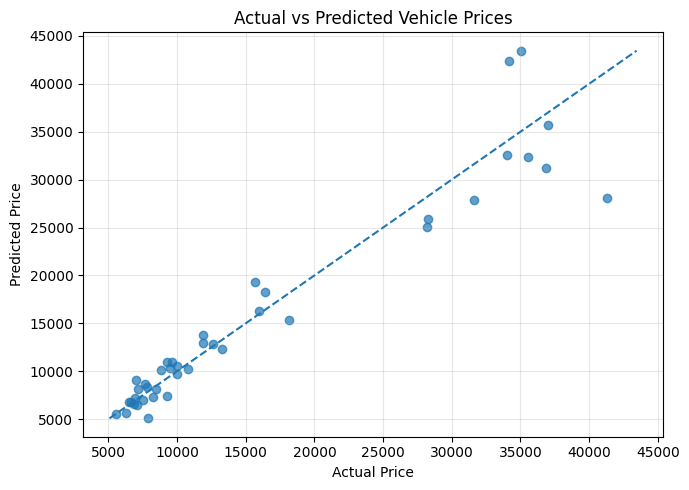

In [40]:
plt.figure(figsize=(7, 5))

plt.scatter(
    y_test_reg,
    y_test_reg_pred,
    alpha=0.7
)

# Ideal prediction line
minimum_price = min(y_test_reg.min(), y_test_reg_pred.min())
maximum_price = max(y_test_reg.max(), y_test_reg_pred.max())

plt.plot(
    [minimum_price, maximum_price],
    [minimum_price, maximum_price],
    linestyle="--"
)

plt.title("Actual vs Predicted Vehicle Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Actual vs Predicted Prices – Interpretation

- Predictions are generally close to the ideal line for low- and mid-priced vehicles.
- Prediction errors become larger for expensive vehicles, showing weaker performance in the upper price range.
- Several high-priced cars are underpredicted, while a few are noticeably overpredicted.
- The increasing spread at higher prices suggests that the Linear Regression model may not capture all premium-vehicle pricing patterns.

Overall, I am OK with those initial results, this is our first model with no tuning done yet - we can check evaluation metrics later on as well to confirm how well this is performing (not only relying on the visual)

## Linear Regression Evaluation

In [45]:
regression_metrics = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MAE": [
        mean_absolute_error(y_train_reg, y_train_reg_pred),
        mean_absolute_error(y_test_reg, y_test_reg_pred)
    ],
    "MSE": [
        mean_squared_error(y_train_reg, y_train_reg_pred),
        mean_squared_error(y_test_reg, y_test_reg_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_train_reg, y_train_reg_pred)),
        np.sqrt(mean_squared_error(y_test_reg, y_test_reg_pred))
    ],
    "R²": [
        r2_score(y_train_reg, y_train_reg_pred),
        r2_score(y_test_reg, y_test_reg_pred)
    ]
})

display(regression_metrics.round(3))

,Dataset,MAE,MSE,RMSE,R²
0,Training,890.318,1.391413e+06,1179.582,0.970
1,Testing,2031.491,1.088380e+07,3299.060,0.911


#### Performance Interpretation - Linear Regression Model

- The model explains **97.0%** of price variation in the training data and **91.1%** in the testing data.
- The test MAE is approximately **\$2,031**, meaning predictions differ from actual prices by about **\$2,031 on average**.
- The test RMSE is approximately **\$3,299**, indicating that a few larger prediction errors affect performance.
- The drop from training to testing performance suggests **some overfitting**, but the model still generalises reasonably well overall.

## Logistic Regression

### Encoding & Scaling the Classification Features (same features as linear reg)

In [47]:
# Identify feature types - those are the same features we used for the linear regression model
categorical_features_cls = X_train_cls.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features_cls = X_train_cls.select_dtypes(
    include=np.number
).columns.tolist()

# Classification preprocessing
cls_preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", StandardScaler(), numerical_features_cls),
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features_cls
        )
    ]
)

# Fit on training data and apply to testing data
X_train_cls_processed = cls_preprocessor.fit_transform(X_train_cls)
X_test_cls_processed = cls_preprocessor.transform(X_test_cls)

print("Processed training shape:", X_train_cls_processed.shape)
print("Processed testing shape:", X_test_cls_processed.shape)

Processed training shape: (160, 63)
Processed testing shape: (41, 63)


### Training the Model

In [48]:
logistic_model = LogisticRegression(
    penalty=None,
    solver="lbfgs",
    max_iter=2000
)

logistic_model.fit(
    X_train_cls_processed,
    y_train_cls
)

# Predicted class labels
y_train_cls_pred = logistic_model.predict(X_train_cls_processed)
y_test_cls_pred = logistic_model.predict(X_test_cls_processed)

# Predicted probability of LuxuryCar = 1
y_train_cls_proba = logistic_model.predict_proba(
    X_train_cls_processed
)[:, 1]

y_test_cls_proba = logistic_model.predict_proba(
    X_test_cls_processed
)[:, 1]

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [50]:
classification_predictions = pd.DataFrame({
    "Actual Class": y_test_cls.reset_index(drop=True),
    "Predicted Class": y_test_cls_pred,
    "Luxury Probability": y_test_cls_proba
})

display(classification_predictions.head(10))

,Actual Class,Predicted Class,Luxury Probability
0,0,0,2.759964e-68
1,1,1,1.000000e+00
2,1,1,1.000000e+00
3,0,0,2.584002e-37
4,0,0,1.110421e-77
5,0,0,2.568339e-117
6,1,1,1.000000e+00
7,1,1,1.000000e+00
8,0,0,4.965081e-51
9,1,1,1.000000e+00


Very over confident results, which suggest that further investigation is needed through the evaluation of both train and test datasets in the next section

## Logistic Regression Evaluation

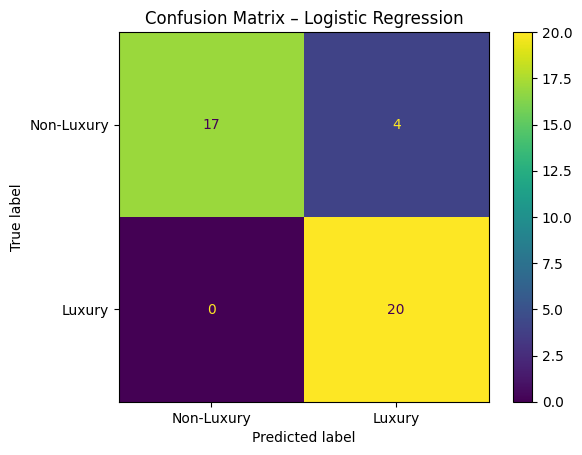

In [54]:
cm = confusion_matrix(
    y_test_cls,
    y_test_cls_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Luxury", "Luxury"]
)

disp.plot()
plt.title("Confusion Matrix – Logistic Regression")
plt.grid(False)
plt.show()

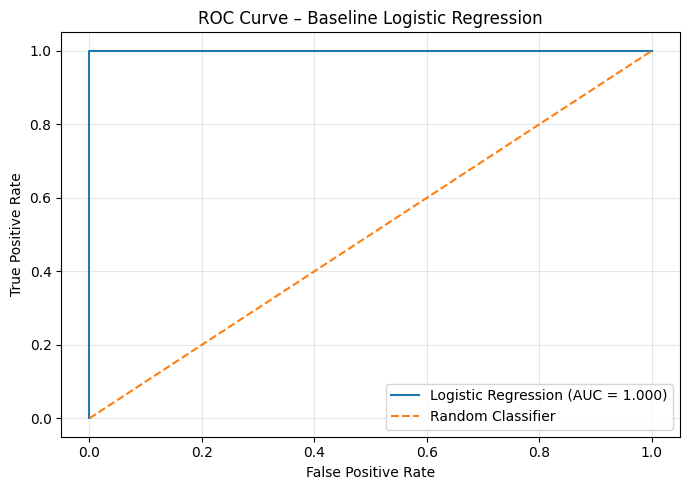

In [63]:
# ROC Curve for the baseline Logistic Regression model
fpr, tpr, thresholds = roc_curve(
    y_test_cls,
    y_test_cls_proba
)

test_auc = roc_auc_score(
    y_test_cls,
    y_test_cls_proba
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {test_auc:.3f})"
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve – Baseline Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### ROC Curve
Almost too good to be true! Which requires some investigation


The ROC-AUC score of **1.00** indicates perfect ranking: every luxury vehicle received a higher predicted probability than every non-luxury vehicle. However, the model (see below) was not perfectly accurate at the default 0.50 threshold, as four non-luxury vehicles were classified as luxury. This means that another probability threshold could potentially separate the two classes perfectly on this test set. The result should nevertheless be interpreted cautiously because of the small test sample and the model's extremely confident probabilities.

**Full-dataset imputation may have contributed a small optimistic bias, but the perfect AUC is more likely explained by strong class separation, the small test sample and the unregularised model.**

In [53]:
classification_metrics = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "Accuracy": [
        accuracy_score(y_train_cls, y_train_cls_pred),
        accuracy_score(y_test_cls, y_test_cls_pred)
    ],
    "Precision": [
        precision_score(y_train_cls, y_train_cls_pred),
        precision_score(y_test_cls, y_test_cls_pred)
    ],
    "Recall": [
        recall_score(y_train_cls, y_train_cls_pred),
        recall_score(y_test_cls, y_test_cls_pred)
    ],
    "F1-Score": [
        f1_score(y_train_cls, y_train_cls_pred),
        f1_score(y_test_cls, y_test_cls_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_train_cls, y_train_cls_proba),
        roc_auc_score(y_test_cls, y_test_cls_proba)
    ]
})

display(classification_metrics.round(3))

,Dataset,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Training,0.994,0.988,1.0,0.994,1.0
1,Testing,0.902,0.833,1.0,0.909,1.0


#### Logistic Regression Performance – Initial Interpretation

- The model achieved **99.4% training accuracy** and **90.2% testing accuracy**, indicating strong performance with some overfitting.
- Testing recall is **1.00**, meaning all actual luxury vehicles were correctly identified.
- Testing precision is lower at **0.833**, showing that some non-luxury vehicles were incorrectly classified as luxury.
- The testing F1-score of **0.909** indicates a strong balance between precision and recall.
- ROC-AUC is **1.00**, meaning the model ranked luxury vehicles above non-luxury vehicles perfectly, even though the default classification threshold still produced some errors.
- The extreme probabilities and train-test gap suggest that regularisation may help produce a more stable model.

## Feature Selection & Generalization

### Training models using Important features Only

In [55]:
# top 15 features
reg_selector = SelectKBest(
    score_func=f_regression,
    k=15
)

X_train_reg_selected = reg_selector.fit_transform(
    X_train_reg_processed,
    y_train_reg
)

X_test_reg_selected = reg_selector.transform(
    X_test_reg_processed
)

# Train Linear Regression using selected features
linear_model_selected = LinearRegression()

linear_model_selected.fit(
    X_train_reg_selected,
    y_train_reg
)

# Generate predictions
y_train_reg_selected_pred = linear_model_selected.predict(
    X_train_reg_selected
)

y_test_reg_selected_pred = linear_model_selected.predict(
    X_test_reg_selected
)

print("Selected training shape:", X_train_reg_selected.shape)
print("Selected testing shape:", X_test_reg_selected.shape)

Selected training shape: (160, 15)
Selected testing shape: (41, 15)


In [56]:
reg_feature_comparison = pd.DataFrame({
    "Model": ["All Features", "Selected 15 Features"],
    "Train RMSE": [
        np.sqrt(mean_squared_error(y_train_reg, y_train_reg_pred)),
        np.sqrt(mean_squared_error(y_train_reg, y_train_reg_selected_pred))
    ],
    "Test RMSE": [
        np.sqrt(mean_squared_error(y_test_reg, y_test_reg_pred)),
        np.sqrt(mean_squared_error(y_test_reg, y_test_reg_selected_pred))
    ],
    "Train R²": [
        r2_score(y_train_reg, y_train_reg_pred),
        r2_score(y_train_reg, y_train_reg_selected_pred)
    ],
    "Test R²": [
        r2_score(y_test_reg, y_test_reg_pred),
        r2_score(y_test_reg, y_test_reg_selected_pred)
    ]
})

display(reg_feature_comparison.round(3))

,Model,Train RMSE,Test RMSE,Train R²,Test R²
0,All Features,1179.582,3299.060,0.970,0.911
1,Selected 15 Features,2411.341,4841.968,0.873,0.808


#### Feature Selection – Linear Regression Interpretation

- Using all features produced the stronger model, with a lower test RMSE (**\$3,299**) and higher test \(R^2\) (**0.911**).
- Reducing the model to 15 features increased test RMSE to **\$4,842** and reduced test \(R^2\) to **0.808**.
- The selected-feature model underfit the data because important pricing information was removed.
- In this case, additional features improved prediction performance, although the full model still showed a moderate train-test gap.

## Regularisation

### Ridge & Lasso

In [57]:
# Candidate regularisation strengths
alpha_values = np.logspace(-3, 4, 100)

# Ridge Regression
ridge_model = RidgeCV(
    alphas=alpha_values,
    cv=5
)

ridge_model.fit(
    X_train_reg_processed,
    y_train_reg
)

# Lasso Regression
lasso_model = LassoCV(
    alphas=alpha_values,
    cv=5,
    max_iter=20000
)

lasso_model.fit(
    X_train_reg_processed,
    y_train_reg
)

# Generate predictions - using all features as we established the results was better
ridge_train_pred = ridge_model.predict(X_train_reg_processed)
ridge_test_pred = ridge_model.predict(X_test_reg_processed)

lasso_train_pred = lasso_model.predict(X_train_reg_processed)
lasso_test_pred = lasso_model.predict(X_test_reg_processed)

print(f"Selected Ridge alpha: {ridge_model.alpha_:.4f}")
print(f"Selected Lasso alpha: {lasso_model.alpha_:.4f}")

Selected Ridge alpha: 0.7925
Selected Lasso alpha: 5.5908


In [58]:
regularisation_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    "Alpha": [
        np.nan,
        ridge_model.alpha_,
        lasso_model.alpha_
    ],
    "Train RMSE": [
        np.sqrt(mean_squared_error(y_train_reg, y_train_reg_pred)),
        np.sqrt(mean_squared_error(y_train_reg, ridge_train_pred)),
        np.sqrt(mean_squared_error(y_train_reg, lasso_train_pred))
    ],
    "Test RMSE": [
        np.sqrt(mean_squared_error(y_test_reg, y_test_reg_pred)),
        np.sqrt(mean_squared_error(y_test_reg, ridge_test_pred)),
        np.sqrt(mean_squared_error(y_test_reg, lasso_test_pred))
    ],
    "Train R²": [
        r2_score(y_train_reg, y_train_reg_pred),
        r2_score(y_train_reg, ridge_train_pred),
        r2_score(y_train_reg, lasso_train_pred)
    ],
    "Test R²": [
        r2_score(y_test_reg, y_test_reg_pred),
        r2_score(y_test_reg, ridge_test_pred),
        r2_score(y_test_reg, lasso_test_pred)
    ]
})

display(regularisation_comparison.round(3))

,Model,Alpha,Train RMSE,Test RMSE,Train R²,Test R²
0,Linear Regression,NaN,1179.582,3299.060,0.970,0.911
1,Ridge Regression,0.792,1445.427,3030.869,0.954,0.925
2,Lasso Regression,5.591,1325.281,2814.789,0.962,0.935


#### Regularisation – Linear Regression Interpretation

- Both Ridge and Lasso improved testing performance compared with ordinary Linear Regression.
- Ridge reduced test RMSE from **\$3,299** to **\$3,031** and increased test \(R^2\) from **0.911** to **0.925**.
- Lasso performed best, reducing test RMSE further to **\$2,815** and increasing test \(R^2\) to **0.935**.
- The slightly weaker training performance but stronger testing results indicate reduced overfitting and improved generalisation.
- Overall, Lasso provided the best balance between model fit and performance on unseen vehicles.

### L1 & L2 Logistic Regression

In [59]:
# Candidate C values
c_values = np.logspace(-3, 3, 50)

# Logistic Regression with L1 regularisation
logistic_l1 = LogisticRegressionCV(
    Cs=c_values,
    cv=5,
    penalty="l1",
    solver="liblinear",
    scoring="roc_auc",
    max_iter=5000
)

logistic_l1.fit(
    X_train_cls_processed,
    y_train_cls
)

# Logistic Regression with L2 regularisation
logistic_l2 = LogisticRegressionCV(
    Cs=c_values,
    cv=5,
    penalty="l2",
    solver="lbfgs",
    scoring="roc_auc",
    max_iter=5000
)

logistic_l2.fit(
    X_train_cls_processed,
    y_train_cls
)

print(f"Selected L1 C: {logistic_l1.C_[0]:.4f}")
print(f"Selected L2 C: {logistic_l2.C_[0]:.4f}")

Selected L1 C: 2.6827
Selected L2 C: 1.5264


In [60]:
# L1 predictions
l1_train_pred = logistic_l1.predict(X_train_cls_processed)
l1_test_pred = logistic_l1.predict(X_test_cls_processed)

l1_train_proba = logistic_l1.predict_proba(
    X_train_cls_processed
)[:, 1]

l1_test_proba = logistic_l1.predict_proba(
    X_test_cls_processed
)[:, 1]

# L2 predictions
l2_train_pred = logistic_l2.predict(X_train_cls_processed)
l2_test_pred = logistic_l2.predict(X_test_cls_processed)

l2_train_proba = logistic_l2.predict_proba(
    X_train_cls_processed
)[:, 1]

l2_test_proba = logistic_l2.predict_proba(
    X_test_cls_processed
)[:, 1]

In [61]:
logistic_regularisation_comparison = pd.DataFrame({
    "Model": [
        "No Regularisation",
        "L1 Logistic Regression",
        "L2 Logistic Regression"
    ],
    "C": [
        np.nan,
        logistic_l1.C_[0],
        logistic_l2.C_[0]
    ],
    "Train Accuracy": [
        accuracy_score(y_train_cls, y_train_cls_pred),
        accuracy_score(y_train_cls, l1_train_pred),
        accuracy_score(y_train_cls, l2_train_pred)
    ],
    "Test Accuracy": [
        accuracy_score(y_test_cls, y_test_cls_pred),
        accuracy_score(y_test_cls, l1_test_pred),
        accuracy_score(y_test_cls, l2_test_pred)
    ],
    "Test Precision": [
        precision_score(y_test_cls, y_test_cls_pred),
        precision_score(y_test_cls, l1_test_pred),
        precision_score(y_test_cls, l2_test_pred)
    ],
    "Test Recall": [
        recall_score(y_test_cls, y_test_cls_pred),
        recall_score(y_test_cls, l1_test_pred),
        recall_score(y_test_cls, l2_test_pred)
    ],
    "Test F1": [
        f1_score(y_test_cls, y_test_cls_pred),
        f1_score(y_test_cls, l1_test_pred),
        f1_score(y_test_cls, l2_test_pred)
    ],
    "Test ROC-AUC": [
        roc_auc_score(y_test_cls, y_test_cls_proba),
        roc_auc_score(y_test_cls, l1_test_proba),
        roc_auc_score(y_test_cls, l2_test_proba)
    ]
})

display(logistic_regularisation_comparison.round(3))

,Model,C,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,No Regularisation,NaN,0.994,0.902,0.833,1.00,0.909,1.000
1,L1 Logistic Regression,2.683,0.969,0.902,0.864,0.95,0.905,0.993
2,L2 Logistic Regression,1.526,0.962,0.902,0.864,0.95,0.905,0.990


#### Regularisation – Logistic Regression Interpretation

- All three models achieved the same testing accuracy of **90.2%**.
- L1 and L2 improved test precision from **0.833** to **0.864**, reducing false luxury predictions.
- Recall decreased slightly from **1.00** to **0.95**, meaning one luxury vehicle was likely missed.
- The baseline model retained the highest F1-score and ROC-AUC, but its near-perfect training accuracy suggests greater overfitting.
- L1 and L2 reduced the training accuracy and produced a smaller train-test gap, indicating more controlled and stable models.
- L1 and L2 performed almost identically, with L1 having a slightly higher ROC-AUC.

## Final Conclusion

The Automobile dataset required missing-value treatment, categorical encoding and numerical scaling before model training. Exploratory analysis showed that vehicle price was positively skewed and was strongly associated with `engine-size`, `curb-weight`, `horsepower`, vehicle dimensions and drive-wheel configuration. More expensive vehicles also tended to have lower fuel efficiency.

The baseline Linear Regression model performed strongly, explaining **91.1%** of the variation in test vehicle prices, with a test MAE of approximately **\$2,031** and RMSE of approximately **\$3,299**. The larger errors were mainly observed among expensive vehicles. Reducing the model to 15 selected features weakened performance, suggesting that the removed variables still contained useful pricing information.

Regularisation improved the Linear Regression results. Ridge reduced the test RMSE to approximately **\$3,031**, while Lasso achieved the best result with a test RMSE of approximately **\$2,815** and test \(R^2\) of **0.935**. This suggests that controlling coefficient size improved generalisation.

The baseline Logistic Regression model achieved **90.2% testing accuracy**, correctly identifying all luxury vehicles but incorrectly classifying four non-luxury vehicles as luxury. Its very confident probabilities and near-perfect training performance suggested some overfitting. L1 and L2 regularisation retained the same testing accuracy while improving precision and reducing the train-test performance gap, although recall decreased slightly.

Overall, both regression and classification models performed well. The results show that vehicle size, engine characteristics, power, fuel efficiency and design features provide strong information for predicting price and identifying luxury vehicles. Regularisation was useful for producing more stable models, while aggressive feature reduction did not improve performance for this dataset.

A limitation of the analysis is the relatively small dataset and the presence of rare vehicle categories. Predictor imputation was also completed before the train-test split, which introduces a minor risk of information leakage. These limitations should be considered when interpreting the final model performance.